In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
ev=pd.read_csv("Eletric_vechile.csv")

In [3]:
ev.head()

,Brand,Model,Price,Range,Battery,Weight
0,BMW,iX3 50 xDrive (MY26),"£58,755",610 km,108.7 kWh,2360 kg
1,Volvo,EX60 P6 (MY27),"£56,860",455 km,80.0 kWh,2190 kg
2,Volvo,EX60 P12 AWD (MY27),"£64,860",610 km,112.0 kWh,2405 kg
3,BYD,ATTO 2,"£30,850",245 km,45.1 kWh,1645 kg
4,MG,MG4 Electric 64 kWh,"£29,745",360 km,61.7 kWh,1726 kg


In [4]:
ev.isna().sum()

Brand      0
Model      0
Price      0
Range      0
Battery    0
Weight     0
dtype: int64

In [5]:
ev['Weight'].agg(["max","min","count"])

max      3085 kg
min      1009 kg
count        874
Name: Weight, dtype: object

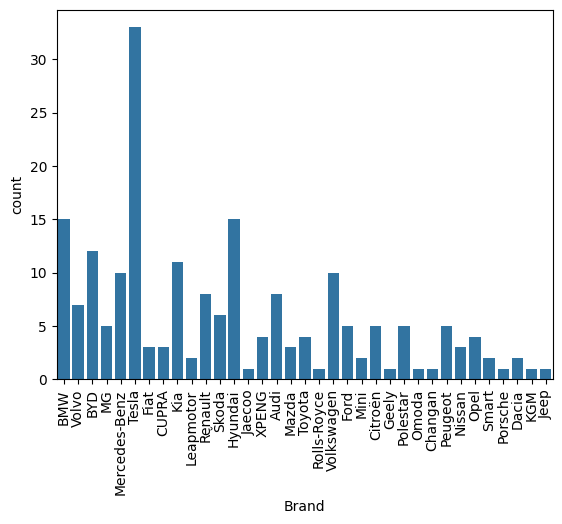

In [6]:
sb.countplot(data=ev.head(200),x="Brand")
plt.xticks(rotation=90)
plt.show()


In [7]:
avg_range = ev.groupby('Brand')['Range'].mean

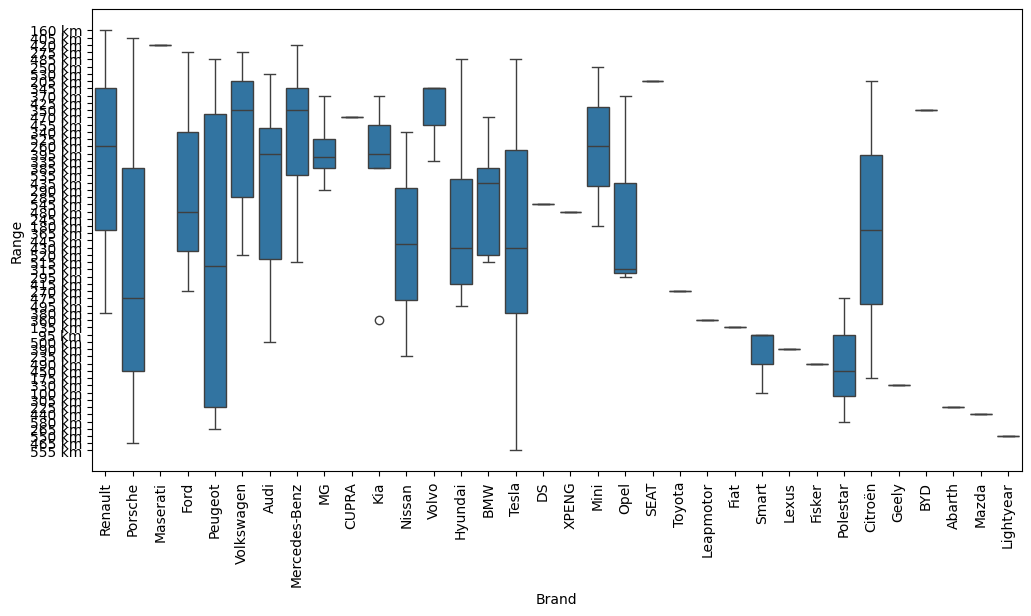

In [8]:
plt.figure(figsize=(12,6)) 
sb.boxplot(x='Brand', y='Range', data=ev.sample(100))
plt.xticks(rotation=90) 
plt.show()

In [9]:
ev['Range']=ev['Range'].str.replace("km","",regex=False)

In [10]:
ev['Range'] = ev['Range'].astype(float)

In [11]:
ev['Price']=ev['Price'].str.replace("£","",regex=False)

In [12]:
ev['Price']=ev['Price'].str.replace("*","",regex=False)

In [13]:
ev['Price'] = ev['Price'].str.replace(",", "", regex=False).astype(float)

In [14]:
ev['Price'] = ev['Price'].astype(float)

In [15]:
ev['Battery']=ev['Battery'].str.replace("kWh","",regex=False).astype(float)

In [16]:
ev

,Brand,Model,Price,Range,Battery,Weight
0,BMW,iX3 50 xDrive (MY26),58755.0,610.0,108.7,2360 kg
1,Volvo,EX60 P6 (MY27),56860.0,455.0,80.0,2190 kg
2,Volvo,EX60 P12 AWD (MY27),64860.0,610.0,112.0,2405 kg
3,BYD,ATTO 2,30850.0,245.0,45.1,1645 kg
4,MG,MG4 Electric 64 kWh,29745.0,360.0,61.7,1726 kg
...,...,...,...,...,...,...
869,Citroën,ë-SpaceTourer XL 50 kWh,37885.0,180.0,46.3,1989 kg
870,Porsche,Taycan Turbo Cross Turismo,126800.0,425.0,83.7,2395 kg
871,Opel,Vivaro-e Combi M 50 kWh,36995.0,185.0,46.3,1969 kg
872,Porsche,Taycan Turbo Sport Turismo,126800.0,405.0,83.7,2405 kg


<Axes: xlabel='Range', ylabel='Price'>

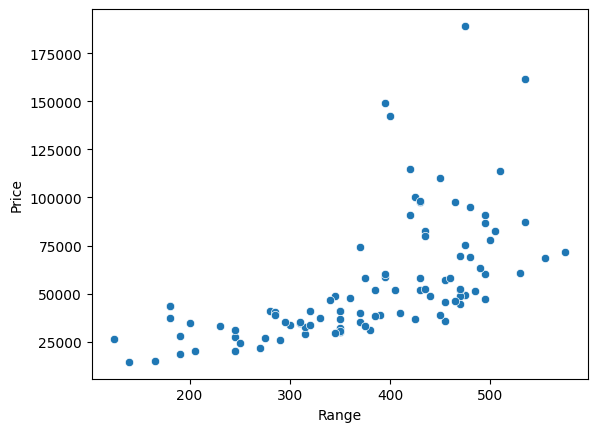

In [17]:
sb.scatterplot(data=ev.sample(100),x="Range",y="Price")

In [18]:
ev['Brand'].unique()

array(['BMW', 'Volvo', 'BYD', 'MG', 'Mercedes-Benz', 'Tesla', 'Fiat',
       'CUPRA', 'Kia', 'Leapmotor', 'Renault', 'Škoda', 'Hyundai',
       'Jaecoo', 'XPENG', 'Audi', 'Mazda', 'Toyota', 'Rolls-Royce',
       'Volkswagen', 'Ford', 'Mini', 'Citroën', 'Geely', 'Polestar',
       'Omoda', 'Changan', 'Peugeot', 'Nissan', 'Opel', 'Smart',
       'Porsche', 'Dacia', 'KGM', 'Jeep', 'Honda', 'Subaru', 'Lexus',
       'Suzuki', 'Maxus', 'Alpine', 'Jaguar', 'GWM', 'DS', 'Alfa',
       'Lightyear', 'Lotus', 'Maserati', 'Fisker', 'Skywell', 'SEAT',
       'Abarth', 'Genesis', 'SsangYong', 'Mitsubishi', 'ORA'],
      dtype=object)

In [19]:
avg_price = ev.groupby('Brand')['Price'].mean().sort_values(ascending=False)
print(avg_price)


Brand
Rolls-Royce      330000.000000
Lightyear        265000.000000
Maserati         158488.333333
Lotus            108414.000000
Porsche          107522.966102
Mercedes-Benz     87352.078125
Audi              74316.727273
BMW               70760.789474
Tesla             67351.967213
Jaguar            66946.666667
Maxus             65290.000000
Genesis           63656.000000
Polestar          60263.928571
Volvo             59411.477273
Ford              56175.450000
Fisker            51645.000000
Lexus             51534.285714
Subaru            49995.000000
Alpine            48195.000000
Volkswagen        46704.178082
Škoda             44442.777778
Hyundai           44271.071429
XPENG             43990.000000
DS                43718.571429
Kia               41956.500000
CUPRA             40934.444444
Changan           39990.000000
Toyota            39682.176471
Skywell           38495.000000
Alfa              38095.000000
MG                37883.333333
Honda             37251.666667
KG

<Axes: xlabel='Brand', ylabel='Price'>

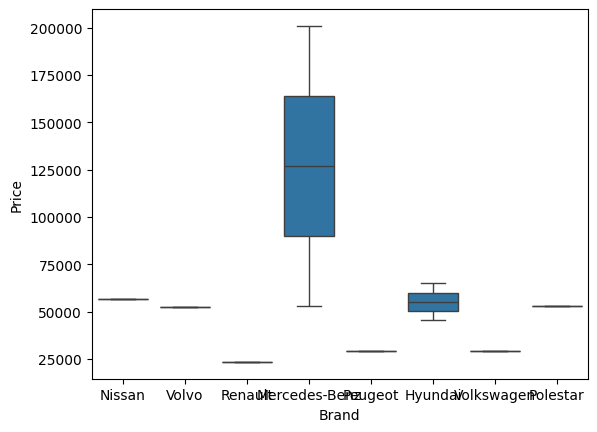

In [20]:
sb.boxplot(x='Brand', y='Price', data=ev.sample(10))

<Axes: xlabel='Brand', ylabel='count'>

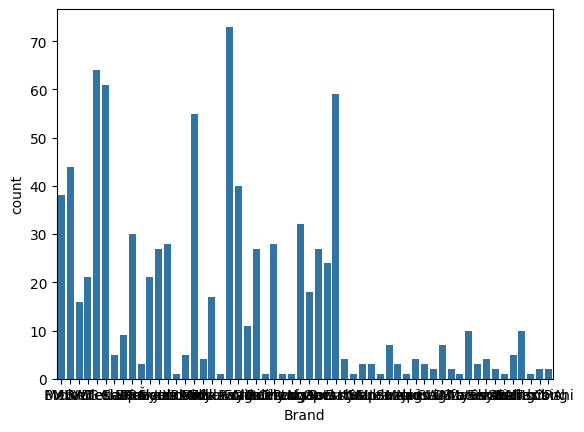

In [21]:
sb.countplot(data=ev,x="Brand")

In [22]:
df=pd.read_csv("df.csv")

In [23]:
merge=pd.merge(df,ev,on="Brand")

In [24]:
merge.drop("Unnamed: 0",axis=1)

,Brand,pickup,Model,Price,Range,Battery,Weight
0,BMW,4.9,iX3 50 xDrive (MY26),58755.0,610.0,108.7,2360 kg
1,BMW,4.9,iX xDrive40,69905.0,360.0,71.0,2440 kg
2,BMW,4.9,iX3 (MY22-24),64165.0,385.0,74.0,2255 kg
3,BMW,4.9,iX1 xDrive30,47465.0,380.0,64.7,2085 kg
4,BMW,4.9,i4 eDrive40,57890.0,515.0,80.7,2125 kg
...,...,...,...,...,...,...,...
42334,Peugeot,12.1,e-Traveller L3 75 kWh,48395.0,265.0,69.0,2240 kg
42335,Peugeot,12.1,e-Traveller L2 75 kWh,47495.0,265.0,69.0,2211 kg
42336,Peugeot,12.1,e-Rifter Long 50 kWh,35120.0,200.0,46.3,1841 kg
42337,Peugeot,12.1,e-Traveller Standard 50 kWh,42785.0,185.0,46.3,1969 kg


In [25]:
top=ev.groupby("Brand")["Price"].mean()

In [26]:
top_ten=top.sort_values(ascending=False).head(10)

Text(0.5, 1.0, 'Brand vs Price')

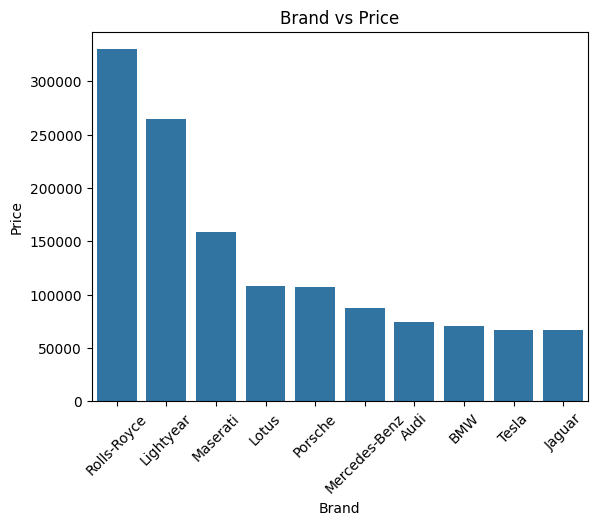

In [27]:
sb.barplot(data=top_ten)
plt.xticks(rotation=45)
plt.title("Brand vs Price")

In [28]:
ev['Weight'] = ev['Weight'].str.replace('kg', '').astype(float)

In [29]:
scat=pd.pivot_table(ev, values=["Price", "Range", "Battery"], index="Brand", aggfunc="mean",sort=True)

<Axes: xlabel='Brand'>

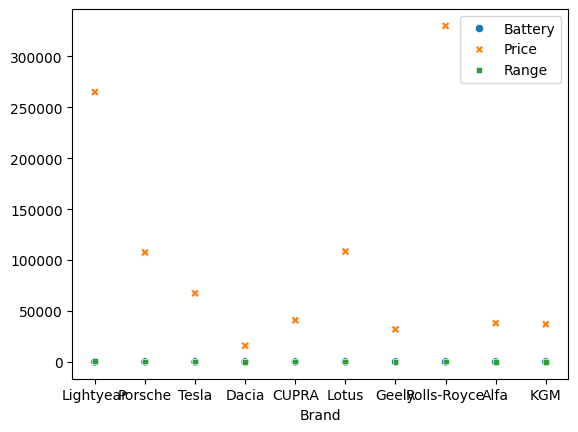

In [30]:
sb.scatterplot(scat.sample(10))

<Axes: >

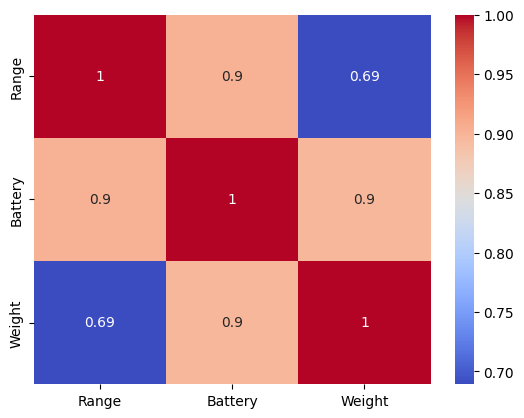

In [31]:
corr = ev[['Range','Battery','Weight']].corr()
sb.heatmap(corr, annot=True, cmap="coolwarm")

In [32]:
ev["Efficiency"]=ev['Range']/ev['Battery']

In [33]:
ev.head(5)

,Brand,Model,Price,Range,Battery,Weight,Efficiency
0,BMW,iX3 50 xDrive (MY26),58755.0,610.0,108.7,2360.0,5.611776
1,Volvo,EX60 P6 (MY27),56860.0,455.0,80.0,2190.0,5.687500
2,Volvo,EX60 P12 AWD (MY27),64860.0,610.0,112.0,2405.0,5.446429
3,BYD,ATTO 2,30850.0,245.0,45.1,1645.0,5.432373
4,MG,MG4 Electric 64 kWh,29745.0,360.0,61.7,1726.0,5.834684


In [34]:
ev.groupby("Model")["Efficiency"].max()

Model
#1 Brabus (MY23)           5.241935
#1 Premium (MY23)          5.403226
#1 Pro (MY24)              5.319149
#1 Pro+ (MY23)             5.403226
#1 Pure (MY24)             5.319149
                             ...   
ë-C4 X 54 kWh              6.594488
ë-SpaceTourer M 50 kWh     3.995680
ë-SpaceTourer M 75 kWh     3.840580
ë-SpaceTourer XL 50 kWh    3.887689
ë-SpaceTourer XL 75 kWh    3.840580
Name: Efficiency, Length: 748, dtype: float64

In [35]:
ev['Efficiency']=ev['Efficiency'].astype(float)

In [36]:
ev.sort_values(ascending=False,by="Efficiency").head()

,Brand,Model,Price,Range,Battery,Weight,Efficiency
362,Lightyear,0,265000.0,550.0,60.0,1575.0,9.166667
9,Tesla,Model 3 Standard RWD (Highland),37990.0,445.0,60.0,1847.0,7.416667
126,Tesla,Model 3 RWD (Highland CATL LFP60),39990.0,420.0,57.0,1836.0,7.368421
124,Tesla,Model 3 Long Range RWD (Highland),44990.0,580.0,79.0,1822.0,7.341772
18,Tesla,Model 3 Premium RWD (Highland),44990.0,580.0,79.0,1822.0,7.341772


<Axes: xlabel='Brand', ylabel='Efficiency'>

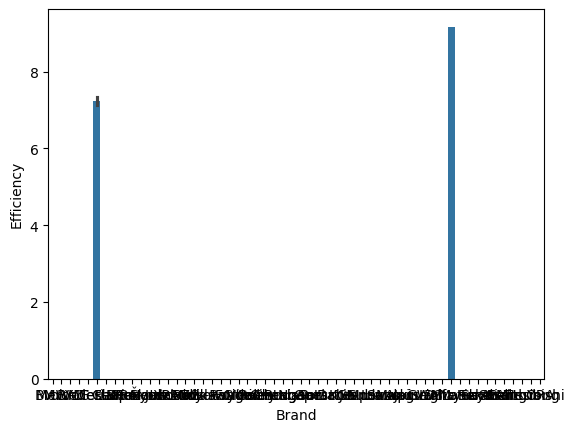

In [37]:
sb.barplot(data=ev,x="Brand",y=ev["Efficiency"].sort_values(ascending=False).head(10))

Text(0.5, 1.0, 'Efficiency vs Brand')

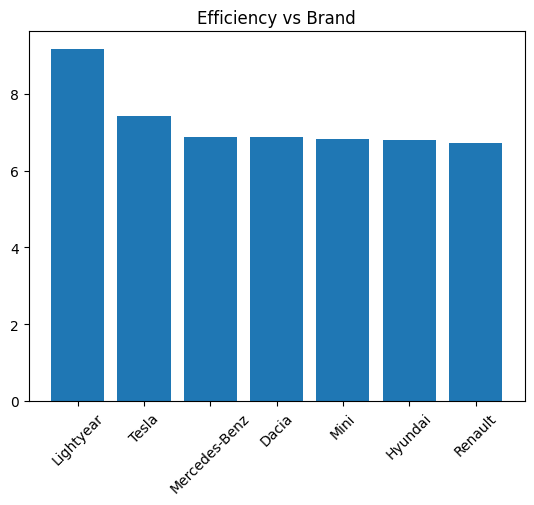

In [38]:
ev_sorted = ev.sort_values("Efficiency", ascending=False)
top10 = ev_sorted.head(20)
plt.bar(top10["Brand"], top10["Efficiency"])
plt.xticks(rotation=45)
plt.title("Efficiency vs Brand")

In [39]:
ev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 874 entries, 0 to 873
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Brand       874 non-null    object 
 1   Model       874 non-null    object 
 2   Price       874 non-null    float64
 3   Range       874 non-null    float64
 4   Battery     874 non-null    float64
 5   Weight      874 non-null    float64
 6   Efficiency  874 non-null    float64
dtypes: float64(5), object(2)
memory usage: 47.9+ KB


In [40]:
ev.columns

Index(['Brand', 'Model', 'Price', 'Range', 'Battery', 'Weight', 'Efficiency'], dtype='object')

In [41]:
merge=merge.drop("Unnamed: 0",axis=1)

In [42]:
merge.groupby("Brand")["pickup"].mean().sort_values(ascending=False)

Brand
Dacia            15.712500
Mitsubishi       13.233333
SEAT             12.300000
Citroën          11.977778
Renault          11.236667
Peugeot          11.109302
Opel             10.592105
Fiat             10.400000
Toyota           10.028571
Lightyear        10.000000
Skywell           9.600000
Maxus             9.200000
Nissan            9.145000
Jeep              8.833333
Mazda             8.700000
Suzuki            8.566667
SsangYong         8.500000
KGM               8.450000
Honda             8.300000
ORA               8.233333
Volkswagen        8.068293
Kia               8.025000
Smart             7.876923
Leapmotor         7.800000
DS                7.771429
Jaecoo            7.700000
Omoda             7.600000
GWM               7.600000
Alfa              7.500000
Hyundai           7.500000
BYD               7.372727
Škoda             7.262162
Mini              7.118182
Mercedes-Benz     7.060526
Changan           6.966667
Geely             6.900000
CUPRA             6.73

In [45]:
merge.to_csv("Electric_Vehicle_Data.csv")